## _Input Data, Detector Layout, Distributions_

In [1]:
import sys, os, glob, yaml

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import pprint
import seaborn as sns
import trackml.dataset

In [4]:
import torch
from torch_geometric.data import Data
import itertools

In [5]:
# append parent dir
sys.path.append('..')

# local imports
from src import Compose_Event, Draw_Compose_Event

## _Input Data_

In [6]:
# mu- data (old)
# input_dir = './data_sets/pandaml/data_3.0_7.0_GeV/'

# mu+mu- data (current)
input_dir = '../train_all'

# pbarp data (coming)
# input_dir = os.environ['HOME']+'/current/2_deepana/pandaml/data/'

In [7]:
# Find All Input Data Files (hits.csv, cells.csv, particles.csv, truth.csv)
all_files = os.listdir(input_dir)
all_files[:10]

['event0000000003-particles.csv',
 'event0000000007-truth.csv',
 'event0000000001-cells.csv',
 'event0000000006-cells.csv',
 'event0000000001-particles.csv',
 'event0000000006-hits.csv',
 'event0000000002-particles.csv',
 'event0000000006-truth.csv',
 'event0000000007-cells.csv',
 'event0000000005-truth.csv']

In [8]:
# Extract File Prefixes (use e.g. xxx-hits.csv)
suffix = '-hits.csv'
file_prefixes = sorted(os.path.join(input_dir, f.replace(suffix, '')) for f in all_files if f.endswith(suffix))
file_prefixes[:10]

['../train_all/event0000000000',
 '../train_all/event0000000001',
 '../train_all/event0000000002',
 '../train_all/event0000000003',
 '../train_all/event0000000004',
 '../train_all/event0000000005',
 '../train_all/event0000000006',
 '../train_all/event0000000007',
 '../train_all/event0000000008',
 '../train_all/event0000000009']

In [9]:
# number of events
len(file_prefixes)

10

In [10]:
# OR, Extract File Prefixes (only works if we don't have any additional files e.g. *.root, *.log etc.)
all_events = sorted(np.unique([os.path.join(input_dir, event[:15]) for event in all_files]))
all_events[:10]

['../train_all/event0000000000',
 '../train_all/event0000000001',
 '../train_all/event0000000002',
 '../train_all/event0000000003',
 '../train_all/event0000000004',
 '../train_all/event0000000005',
 '../train_all/event0000000006',
 '../train_all/event0000000007',
 '../train_all/event0000000008',
 '../train_all/event0000000009']

In [11]:
# number of events (in addition to *.csv, *.root and *.log files exists in this dir.)
len(all_events)

10

In [12]:
event_id = 1

In [13]:
# Fetch an event, use event_id (int)
prefix = "event{:010d}".format(event_id)                     # OR, 
prefix = str('event{!s}'.format(format(event_id, '010d')))   # a little better
event_prefix = os.path.join(input_dir, prefix)              # event_prefix ~ event_file = input_dir + prefix

In [14]:
hits, tubes, particles, truth = trackml.dataset.load_event(event_prefix)

In [15]:
hits.head()

,hit_id,x,y,z,volume_id,layer_id,module_id
0,1,-1.745690,4.42021,0.881106,2,6,39
1,2,1.769520,-1.15347,2.420000,2,2,273
2,3,3.964660,-2.63097,5.443500,2,6,10
3,4,2.250330,4.17722,-7.071880,2,6,23
4,5,0.957682,1.98469,-3.248450,2,1,29


In [16]:
# OR, use event_id to fectch one file from list of all files
event_prefix = file_prefixes[event_id]
print(event_prefix)

../train_all/event0000000001


In [17]:
# load an event
hits, tubes, particles, truth = trackml.dataset.load_event(event_prefix)

# memory usage
mem_bytes = (hits.memory_usage(index=True).sum() 
             + tubes.memory_usage(index=True).sum() 
             + particles.memory_usage(index=True).sum() 
             + truth.memory_usage(index=True).sum())

print('{} memory usage {:.2f} MB'.format(os.path.basename(event_prefix), mem_bytes / 2**20))

event0000000001 memory usage 0.03 MB


In [18]:
hits.head()

,hit_id,x,y,z,volume_id,layer_id,module_id
0,1,-1.745690,4.42021,0.881106,2,6,39
1,2,1.769520,-1.15347,2.420000,2,2,273
2,3,3.964660,-2.63097,5.443500,2,6,10
3,4,2.250330,4.17722,-7.071880,2,6,23
4,5,0.957682,1.98469,-3.248450,2,1,29


In [19]:
tubes.head()

,hit_id,depcharge,energyloss,volume_id,layer_id,module_id,sector_id,isochrone,skewed
0,1,14536.0,0.000052,2,6,39,NaN,NaN,NaN
1,2,19648.0,0.000071,2,2,273,NaN,NaN,NaN
2,3,19357.2,0.000070,2,6,10,NaN,NaN,NaN
3,4,43691.2,0.000158,2,6,23,NaN,NaN,NaN
4,5,34984.1,0.000126,2,1,29,NaN,NaN,NaN


In [20]:
particles.head()

,particle_id,vx,vy,vz,px,py,pz,q,nhits,pdgcode,start_time,primary
0,1,0.0,0.0,0.0,0.737403,-0.161757,-0.468708,1,30,13,0,1
1,3,0.0,0.0,0.0,0.336343,0.236929,-0.099397,1,26,13,0,1
2,5,0.0,0.0,0.0,0.665995,0.641657,0.234167,1,27,13,0,1
3,6,0.0,0.0,0.0,0.357977,-0.229329,0.488361,-1,31,-13,0,1
4,7,0.0,0.0,0.0,0.387590,0.854636,-0.418559,-1,28,-13,0,1


In [21]:
truth.head()

,hit_id,tx,ty,tz,tpx,tpy,tpz,weight,particle_id
0,1,-1.744380,4.40974,0.878602,-0.244687,0.638028,0.126067,1.0,8
1,2,1.762170,-1.14845,2.410000,0.355199,-0.235100,0.486823,1.0,6
2,3,3.956490,-2.62517,5.432730,0.350848,-0.241165,0.486243,1.0,6
3,4,2.246700,4.16787,-7.056110,0.042684,0.060122,-0.116944,1.0,10
4,5,0.952562,1.97610,-3.232980,0.037278,0.070228,-0.119221,1.0,10


### _(1) - Detector Layout_

In [22]:
event = Compose_Event(event_prefix,skewed=True)

In [23]:
event.columns

Index(['hit_id', 'x', 'y', 'z', 'volume_id', 'layer_id', 'module_id',
       'isochrone', 'skewed', 'sector_id', 'r', 'phi', 'tx', 'ty', 'tz', 'tpx',
       'tpy', 'tpz', 'weight', 'particle_id', 'vx', 'vy', 'vz', 'px', 'py',
       'pz', 'q', 'nhits', 'pdgcode', 'start_time', 'primary', 'pt',
       'event_id'],
      dtype='object')

In [24]:
Draw_Compose_Event(event,figsize=(10,10));

ValueError: need at least one array to concatenate

<Figure size 720x720 with 1 Axes>

### _(2) - Draw Individual Tracks_

In [25]:
# preprocess hits
# hits['r'] = hits.apply(lambda row: np.sqrt(row.x**2 + row.y**2), axis=1)
hits_ = hits.assign(r=hits.apply(lambda row: np.sqrt(row.x**2 + row.y**2), axis=1))
hits_.head()

,hit_id,x,y,z,volume_id,layer_id,module_id,r
0,1,-1.745690,4.42021,0.881106,2,6,39,4.752440
1,2,1.769520,-1.15347,2.420000,2,2,273,2.112272
2,3,3.964660,-2.63097,5.443500,2,6,10,4.758207
3,4,2.250330,4.17722,-7.071880,2,6,23,4.744803
4,5,0.957682,1.98469,-3.248450,2,1,29,2.203667


In [26]:
# we already have sorted hits, lets draw a single track.
data = hits_[truth.particle_id == particles.iloc[1,0]]
data.head()

,hit_id,x,y,z,volume_id,layer_id,module_id,r
7,8,2.26770,1.63502,-0.6750,2,1,25,2.795667
21,22,7.22643,5.49408,-2.2235,3,15,69,9.077786
22,23,9.75509,7.58021,-3.0295,3,17,121,12.354002
124,165,13.99500,11.11000,35.0000,9,0,91,17.868747
125,166,14.86970,11.61500,35.0000,9,1,200,18.868392


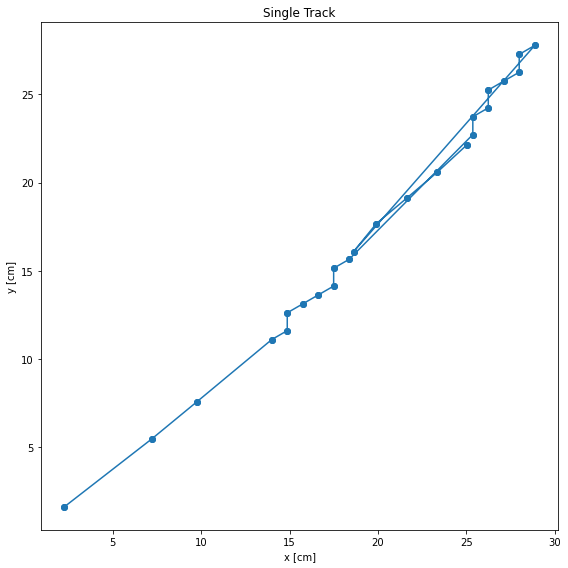

In [27]:
# Using Object Oriented API
fig, ax = plt.subplots(figsize=(8,8))

ax.scatter(data.x.values, data.y.values)
ax.plot(data.x.values, data.y.values, "-o")

ax.set_title('Single Track')
ax.set_xlabel('x [cm]')
ax.set_ylabel('y [cm]')
# ax.set_xlim(-40, 40)
# ax.set_ylim(-40, 40)
fig.tight_layout()
# fig.savefig('event.png')

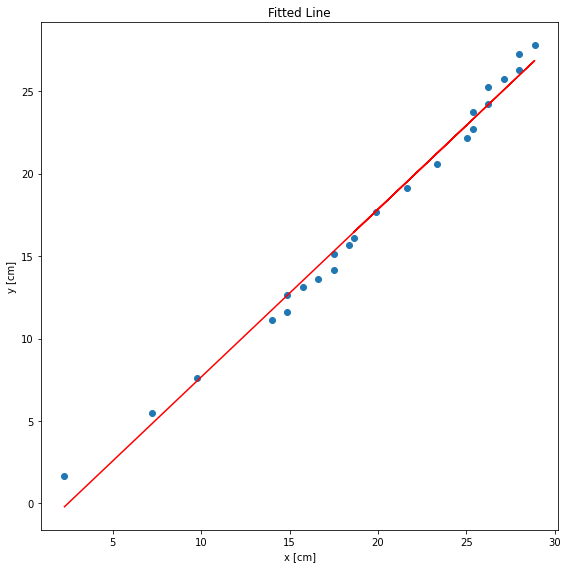

In [28]:
# Using Object Oriented API
plt.close('all')
fig, ax = plt.subplots(figsize=(8,8))

a, b = np.polyfit(data.x, data.y, 1)
y = a*data.x.values + b

ax.scatter(data.x.values, data.y.values)
ax.plot(data.x.values, y, 'r')
ax.set_title('Fitted Line')
ax.set_xlabel('x [cm]')
ax.set_ylabel('y [cm]')
# ax.set_xlim(-40, 40)
# ax.set_ylim(-40, 40)
fig.tight_layout()
# fig.savefig('event.png')

### _(3) - Momentum Distributions_

In [29]:
# calculate & assign pt
particles = particles.assign(pt=np.sqrt(particles.px**2 + particles.py**2))

In [30]:
particles.head()

,particle_id,vx,vy,vz,px,py,pz,q,nhits,pdgcode,start_time,primary,pt
0,1,0.0,0.0,0.0,0.737403,-0.161757,-0.468708,1,30,13,0,1,0.754936
1,3,0.0,0.0,0.0,0.336343,0.236929,-0.099397,1,26,13,0,1,0.411415
2,5,0.0,0.0,0.0,0.665995,0.641657,0.234167,1,27,13,0,1,0.924810
3,6,0.0,0.0,0.0,0.357977,-0.229329,0.488361,-1,31,-13,0,1,0.425134
4,7,0.0,0.0,0.0,0.387590,0.854636,-0.418559,-1,28,-13,0,1,0.938418


In [31]:
particles.pt

0    0.754936
1    0.411415
2    0.924810
3    0.425134
4    0.938418
5    0.683466
6    0.863736
7    0.081411
Name: pt, dtype: float32

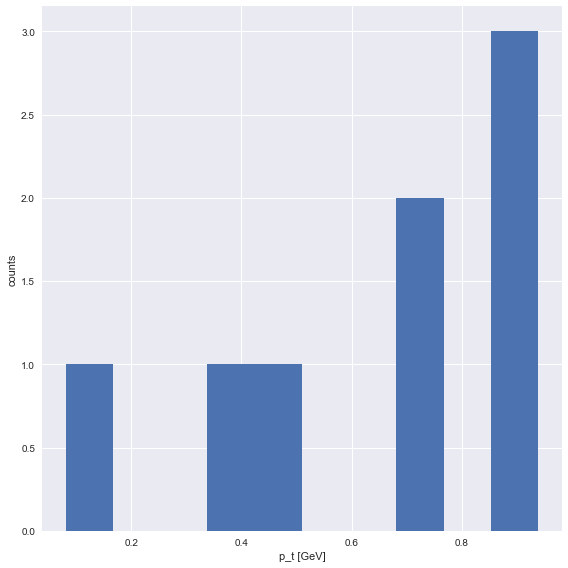

In [32]:
# Using Pyplot API
plt.close('all')
plt.style.use('seaborn')
fig = plt.figure(figsize=(8,8))

plt.hist(particles.pt, bins=10)

plt.xlabel('p_t [GeV]')
plt.ylabel('counts')
# plt.xlim((0.1, 1.5))
# plt.ylim((5, 40))
plt.tight_layout()

In [33]:
# find average hits per track
print("Average number of hits per tracks: {}".format(hits.hit_id.count()/particles.particle_id.unique().size))

Average number of hits per tracks: 26.875


## _Misc._